# Segmentación por **crecimiento de regiones** con validación cruzada de **K = 5**

Aplica **crecimiento de regiones** (*region growing*) a todas las imágenes de `DATASET_FINAL.mat`

* validación cruzada **estratificada por tipo de lesión**, K = 5 pliegues
* reparto por pliegue: **64 %** entrenamiento / **16 %** validación / **20 %** test
* cada imagen actúa como test exactamente una vez
* métricas reportadas como **media** sobre los cinco pliegues

Al terminar, se muestran **5 imágenes**, con cuatro paneles
cada una:

**Original · Segmentación por crecimiento · Ground truth · Contornos superpuestos**

(**verde** = contorno del ground truth, **rojo** = contorno de c.regiones).

> Todas las predicciones que se muestran son **fuera de pliegue** (*out-of-fold*): cada imagen se
> segmenta con la configuración que su pliegue eligió sin haberla visto nunca.

---



### 1. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Parámetros

In [2]:
RUTA_MAT       = "/C:/Users/josem/Desktop/DATASET_FINAL.pdf"
CARPETA_SALIDA = "/content/drive/MyDrive/TFG/resultados_crecimiento"

UMBRAL_DICE   = 0.9      # solo se muestran las imágenes que superen este Dice
MAX_MOSTRAR   = 5        # tope de filas en la figura (None = todas)
POSTPROCESO   = True     # limpieza morfológica + mayor componente conexa
RELLENAR      = True     # rellena los huecos negros dentro de la lesión
GUARDAR       = True     # guardar la figura en CARPETA_SALIDA

REDIMENSIONAR = True     # 256x256, como el resto del pipeline del TFG.
IMG_SIZE      = 256      # Ponlo a False para trabajar a resolución nativa.

# --- validación cruzada ---
N_SPLITS      = 5        # K = 5 pliegues
VAL_FRACTION  = 0.20     # 20 % del 80 % restante = 16 % del total
RANDOM_STATE  = 42       # semilla fija -> pliegues reproducibles

# --- crecimiento de regiones ---
SIGMA_SEMILLA  = 9.0     # suavizado fuerte para localizar la semilla de forma estable
MARGEN_SEMILLA = 0.15    # fracción del borde descartada al buscarla (evita esquinas)
CONECTIVIDAD   = 4       # 4 u 8 vecinos

# Espacio de búsqueda: (canal, criterio de semilla, tolerancia, rango).
#   criterio = "max" -> la semilla va en el punto más alto del canal (más rojizo)
#   criterio = "min" -> en el más bajo (más oscuro)
#   tolerancia       -> cuánto puede diferir un píxel para entrar en la región
#   rango = "fijo"     -> se compara con el valor de LA SEMILLA (más conservador)
#   rango = "flotante" -> se compara con el vecino ya admitido (crece más, se
#                         desborda con más facilidad)
CONFIGS_CANDIDATAS = [
    ("lab_a", "max", 10, "fijo"),      # crominancia rojo-verde: hemangiomas rojizos
    ("lab_a", "max", 15, "fijo"),
    ("lab_a", "max", 20, "fijo"),
    ("lab_a", "max",  8, "flotante"),
    ("hsv_s", "max", 25, "fijo"),      # saturación
    ("gris",  "min", 25, "fijo"),      # la lesión suele ser más oscura que la piel
    ("inv_g", "max", 20, "fijo"),      # verde invertido, realza lo rojizo
    ("rgb_r", "max", 25, "fijo"),      # canal rojo
]

### 3. Importaciones

In [3]:
import os
import h5py
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
from sklearn.model_selection import StratifiedKFold, train_test_split
from collections import Counter

### 4. Lectura del dataset

Idéntica a la del cuaderno de Otsu, para que ambos métodos trabajen exactamente sobre las mismas
imágenes y máscaras. El campo `tipo` es el que **estratifica** los pliegues.

In [5]:
f  = h5py.File(RUTA_MAT, "r")
DS = f["DATASET_UNIDO"]

def leer_entrada(i):
    c = [f[r] for r in f[DS[i, 0]][()].ravel()]
    nombre = "".join(chr(x) for x in c[0][()].ravel())
    tipo   = "".join(chr(x) for x in c[2][()].ravel())
    mask   = (c[1][()].T > 0).astype(np.uint8)                          # (H, W) binaria
    img    = (np.transpose(c[3][()], (2, 1, 0)) * 255).clip(0, 255).astype(np.uint8)
    return nombre, tipo, img, mask


N = DS.shape[0]
nombres, tipos, imagenes, mascaras = [], [], [], []

for i in range(N):
    nombre, tipo, img, gt = leer_entrada(i)
    if REDIMENSIONAR:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        gt  = cv2.resize(gt,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    nombres.append(nombre)
    tipos.append(tipo)
    imagenes.append(img)
    mascaras.append((gt > 0).astype(np.uint8))

etiquetas = np.array(tipos)

### 5. Segmentación por crecimiento de regiones

Dos pasos:

1. **Semilla automática.** Se suaviza el canal con un gaussiano ancho y se toma su máximo (o
   mínimo) dentro de la zona central. El suavizado evita que un píxel de ruido haga de semilla.
2. **Crecimiento.** Se agregan vecinos mientras la diferencia con el criterio de similitud no supere
   la tolerancia. Está implementado con `cv2.floodFill`, que es exactamente un crecimiento de
   regiones por similitud de intensidad, pero en C: hacerlo con un bucle de Python sobre 65 536
   píxeles por imagen sería inviable aquí.

Con `rango = "fijo"` cada píxel se compara con **la semilla**; con `"flotante"`, con el vecino ya
admitido, lo que permite seguir degradados suaves pero se desborda con más facilidad.

Las segmentaciones se **guardan en caché** por (imagen, configuración).

In [6]:
def extraer_canal(img, canal):
    """Devuelve el canal escalar uint8 sobre el que crece la region."""
    if canal == "gris":
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if canal == "lab_a":
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 1]
    if canal == "hsv_s":
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[:, :, 1]
    if canal == "rgb_r":
        return img[:, :, 0]
    if canal == "inv_g":
        return 255 - img[:, :, 1]
    raise ValueError(f"canal desconocido: {canal}")


def localizar_semilla(ch, criterio):
    """Semilla automatica: extremo del canal muy suavizado, lejos del borde."""
    suave = cv2.GaussianBlur(ch.astype(np.float32), (0, 0), SIGMA_SEMILLA)
    h, w = suave.shape
    m = int(round(min(h, w) * MARGEN_SEMILLA))
    interior = suave[m:h - m, m:w - m]
    if interior.size == 0:
        interior, m = suave, 0
    idx = int(np.argmax(interior) if criterio == "max" else np.argmin(interior))
    y, x = np.unravel_index(idx, interior.shape)
    return (int(x + m), int(y + m))          # floodFill espera (x, y)


def segmentar_crecimiento(img, canal="lab_a", criterio="max", tolerancia=15,
                          rango="fijo", postproceso=True, rellenar=True):
    """Crecimiento de regiones desde una semilla colocada automaticamente."""
    h, w = img.shape[:2]
    ch = cv2.GaussianBlur(extraer_canal(img, canal), (5, 5), 0)

    semilla = localizar_semilla(ch, criterio)

    mascara = np.zeros((h + 2, w + 2), np.uint8)     # floodFill la necesita con borde
    banderas = CONECTIVIDAD | (1 << 8) | cv2.FLOODFILL_MASK_ONLY
    if rango == "fijo":
        banderas |= cv2.FLOODFILL_FIXED_RANGE

    cv2.floodFill(ch.copy(), mascara, semilla, 0,
                  tolerancia, tolerancia, banderas)
    seg = mascara[1:-1, 1:-1].astype(np.uint8)

    # --- postproceso identico al del cuaderno de Otsu ---
    if postproceso:
        k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        seg = cv2.morphologyEx(seg, cv2.MORPH_OPEN, k7)
        seg = cv2.morphologyEx(seg, cv2.MORPH_CLOSE, k7)
        nc, lblc = cv2.connectedComponents(seg)
        if nc > 2:                      # conserva la mayor componente conexa
            areas = [(lblc == j).sum() for j in range(1, nc)]
            seg = (lblc == 1 + int(np.argmax(areas))).astype(np.uint8)

    if rellenar:
        seg = binary_fill_holes(seg).astype(np.uint8)

    return seg.astype(np.uint8)


def semilla_de(i, config):
    """Posicion de la semilla usada, para poder dibujarla en las figuras."""
    canal, criterio, _, _ = config
    ch = cv2.GaussianBlur(extraer_canal(imagenes[i], canal), (5, 5), 0)
    return localizar_semilla(ch, criterio)


# --- cache: (indice de imagen, configuracion) -> segmentacion ---
_cache = {}

def segmentacion(i, config):
    clave = (i, config)
    if clave not in _cache:
        canal, criterio, tol, rango = config
        _cache[clave] = segmentar_crecimiento(imagenes[i], canal, criterio, tol,
                                              rango, POSTPROCESO, RELLENAR)
    return _cache[clave]

### 6. Métricas y dibujo de contornos

In [14]:
EPS = 1e-8

def matriz_confusion(pred, gt):
    """Recuento de VP, VN, FP y FN a nivel de píxel."""
    p, g = pred > 0, gt > 0
    return dict(vp=int(( p &  g).sum()), vn=int((~p & ~g).sum()),
                fp=int(( p & ~g).sum()), fn=int((~p &  g).sum()))

def suma_confusion(a, b):
    return {k: a[k] + b[k] for k in a}

def dice_de_confusion(c):
    return (2 * c["vp"] + EPS) / (2 * c["vp"] + c["fp"] + c["fn"] + EPS)

def metricas_de_confusion(c):
    return {
        "exactitud":     (c["vp"] + c["vn"]) / (c["vp"] + c["vn"] + c["fp"] + c["fn"] + EPS),
        "precision":     (c["vp"] + EPS) / (c["vp"] + c["fp"] + EPS),
        "sensibilidad":  (c["vp"] + EPS) / (c["vp"] + c["fn"] + EPS),
        "especificidad": (c["vn"] + EPS) / (c["vn"] + c["fp"] + EPS),
    }

def dice(a, b):
    return dice_de_confusion(matriz_confusion(a, b))


def evaluar(indices, config):
    """Evalúa una configuración de crecimiento sobre un subconjunto de índices.

    Se agrega de las dos formas, igual que en el cuaderno de Otsu (§6.2 de la memoria):
      * Dice -> por imagen y promediado (macro). Cada lesión pesa igual.
      * F1   -> acumulando VP, FP y FN de todas las imágenes (micro). Cada píxel
                pesa igual, así que las lesiones grandes influyen más.
    Comparten fórmula pero no valor."""
    dices, total = [], dict(vp=0, vn=0, fp=0, fn=0)
    for i in indices:
        c = matriz_confusion(segmentacion(i, config), mascaras[i])
        dices.append(dice_de_confusion(c))
        total = suma_confusion(total, c)
    res = metricas_de_confusion(total)
    res["dice"] = float(np.mean(dices))     # macro, por imagen
    res["f1"]   = dice_de_confusion(total)  # micro, global
    return res


def elegir_configuracion(indices_ajuste):
    """Elige la configuración que maximiza el Dice en entrenamiento + validación.
    Ninguna imagen de test interviene en esta decisión."""
    mejor, mejor_dice = None, -1.0
    for config in CONFIGS_CANDIDATAS:
        d = evaluar(indices_ajuste, config)["dice"]
        if d > mejor_dice:
            mejor, mejor_dice = config, d
    return mejor, mejor_dice


def dibujar_contornos(img, seg, gt, grosor=None):
    o = img.copy()
    if grosor is None:
        grosor = max(2, int(round(max(img.shape[:2]) / 300)))
    cont_gt,  _ = cv2.findContours(gt.astype(np.uint8),  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cont_seg, _ = cv2.findContours(seg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(o, cont_gt,  -1, (255, 0, 0), grosor)   # ground truth -> rojo
    cv2.drawContours(o, cont_seg, -1, (0, 255, 0), grosor)   # crecimiento  -> verde
    return o

### 7. Validación cruzada estratificada de 5 pliegues


In [15]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

resultados_pliegue = []
configs_elegidas   = []

seg_oof    = [None] * N
dice_oof   = np.zeros(N)
pliegue_de = np.zeros(N, dtype=int)

print(f"Validación cruzada estratificada de {N_SPLITS} pliegues\n")

for pliegue, (idx_trval, idx_test) in enumerate(skf.split(np.zeros(N), etiquetas), 1):
    try:
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION,
            stratify=etiquetas[idx_trval], random_state=RANDOM_STATE)
    except ValueError:
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION, random_state=RANDOM_STATE)

    # La configuración se decide sobre entrenamiento + validación...
    config, dice_ajuste = elegir_configuracion(np.concatenate([idx_train, idx_val]))
    # ...y se aplica al pliegue de test, no visto en la selección.
    res = evaluar(idx_test, config)

    for i in idx_test:
        s = segmentacion(i, config)
        seg_oof[i]    = s
        dice_oof[i]   = dice(s, mascaras[i])
        pliegue_de[i] = pliegue

    resultados_pliegue.append(res)
    configs_elegidas.append(config)

    canal, criterio, tol, rango = config
    print(f"Pliegue {pliegue}/{N_SPLITS}  "
          f"(train {len(idx_train)} / val {len(idx_val)} / test {len(idx_test)})  "
          f"config = {canal}, semilla {criterio}, tol {tol}, rango {rango}   "
          f"[Dice ajuste {dice_ajuste:.4f}]")
    print(f"    test ->  Dice {res['dice']:.4f}   F1 {res['f1']:.4f}   "
          f"Exac. {res['exactitud']:.4f}   Prec. {res['precision']:.4f}   "
          f"Sens. {res['sensibilidad']:.4f}   Espec. {res['especificidad']:.4f}")

Validación cruzada estratificada de 5 pliegues

Pliegue 1/5  (train 83 / val 21 / test 26)  config = lab_a, semilla max, tol 10, rango fijo   [Dice ajuste 0.7773]
    test ->  Dice 0.8446   F1 0.8364   Exac. 0.9199   Prec. 1.0657   Sens. 0.7010   Espec. 0.9876
Pliegue 2/5  (train 83 / val 21 / test 26)  config = lab_a, semilla max, tol 10, rango fijo   [Dice ajuste 0.7987]
    test ->  Dice 0.7591   F1 0.6505   Exac. 0.8315   Prec. 0.6484   Sens. 0.8856   Espec. 0.8587
Pliegue 3/5  (train 83 / val 21 / test 26)  config = lab_a, semilla max, tol 10, rango fijo   [Dice ajuste 0.7829]
    test ->  Dice 0.8222   F1 0.6613   Exac. 0.7807   Prec. 0.6392   Sens. 0.9894   Espec. 0.7898
Pliegue 4/5  (train 83 / val 21 / test 26)  config = lab_a, semilla max, tol 10, rango fijo   [Dice ajuste 0.8182]
    test ->  Dice 0.6810   F1 0.8809   Exac. 0.8860   Prec. 1.0788   Sens. 0.7821   Espec. 0.9440
Pliegue 5/5  (train 83 / val 21 / test 26)  config = lab_a, semilla max, tol 10, rango fijo   [Dice 

### 8. Resumen: media ± desviación típica sobre los pliegues

In [16]:
CLAVES  = ["exactitud", "precision", "sensibilidad", "especificidad", "dice", "f1"]
NOMBRES = {"exactitud": "Exactitud", "precision": "Precisión",
           "sensibilidad": "Sensibilidad", "especificidad": "Especificidad",
           "dice": "Dice", "f1": "F1"}

resumen = {k: (float(np.mean([r[k] for r in resultados_pliegue])),
               float(np.std ([r[k] for r in resultados_pliegue]))) for k in CLAVES}

print("=" * 60)
print(f"crecimiento de regiones — validación cruzada de {N_SPLITS} pliegues  (n = {N} imágenes)")
print("=" * 60)
print(f"{'Métrica':<16}{'Media':>10}")
print("-" * 60)
for k in CLAVES:
    m, s = resumen[k]
    print(f"{NOMBRES[k]:<16}{m:>10.4f}")
print("-" * 60)



crecimiento de regiones — validación cruzada de 5 pliegues  (n = 130 imágenes)
Métrica              Media
------------------------------------------------------------
Exactitud           0.8524
Precisión           0.8599
Sensibilidad        0.8615
Especificidad       0.8894
Dice                0.7907
F1                  0.7694
------------------------------------------------------------


### 9. Las 5 imágenes


Figura guardada en /content/drive/MyDrive/TFG/resultados_crecimiento/resultados_crecimiento_kfold_dice09.png


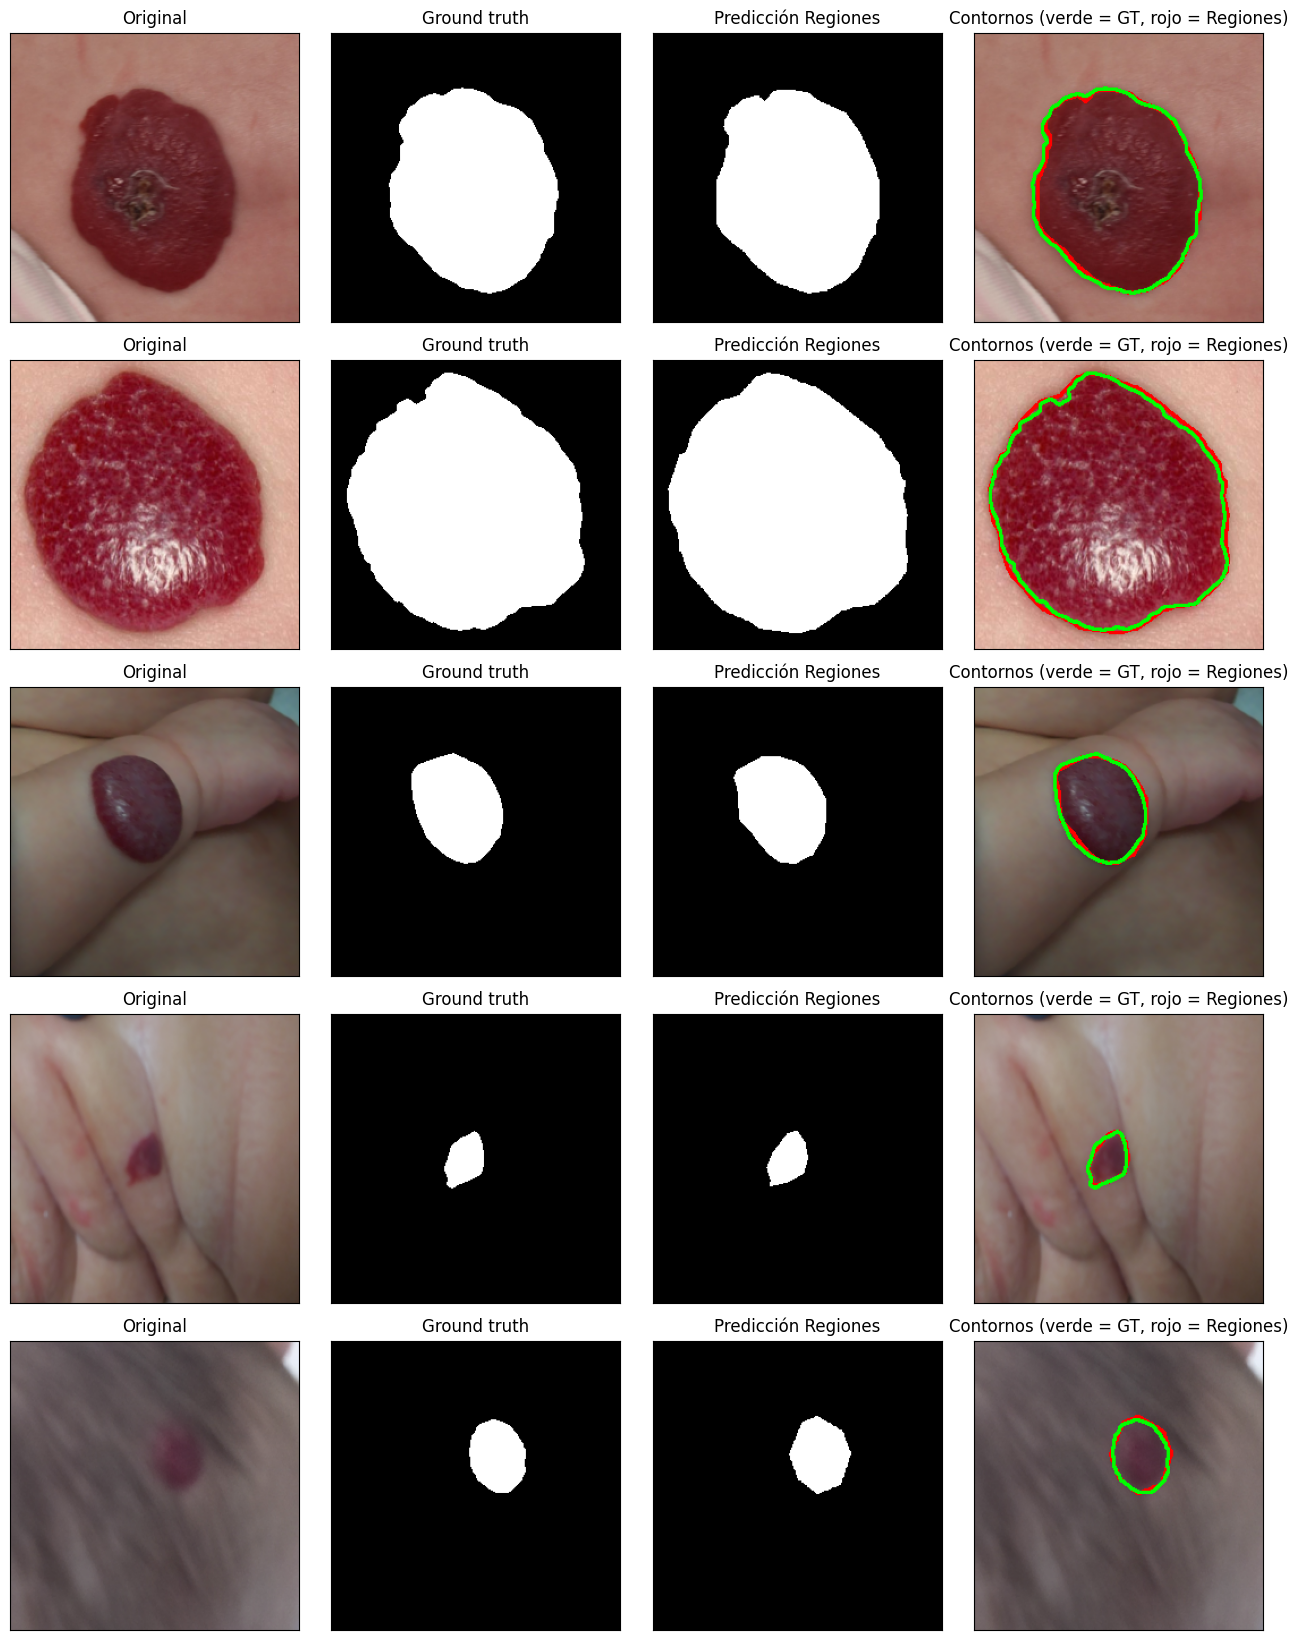

In [12]:
if GUARDAR:
    os.makedirs(CARPETA_SALIDA, exist_ok=True)

buenas = [i for i in range(N) if dice_oof[i] > UMBRAL_DICE]
buenas.sort(key=lambda i: -dice_oof[i])



mostrar = buenas if MAX_MOSTRAR is None else buenas[:MAX_MOSTRAR]
if MAX_MOSTRAR is not None and len(buenas) > MAX_MOSTRAR:


  if not buenas:
    print("\nNinguna imagen supera el umbral.")
  else:
    n = len(mostrar)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for fila, i in enumerate(mostrar):
        img, gt, seg = imagenes[i], mascaras[i], seg_oof[i]
        ax = axes[fila]
        ax[0].imshow(img);              ax[0].set_title("Original")
        ax[1].imshow(seg, cmap="gray"); ax[1].set_title("Ground truth")
        ax[2].imshow(gt,  cmap="gray"); ax[2].set_title("Predicción Regiones")
        ax[3].imshow(dibujar_contornos(img, seg, gt))
        ax[3].set_title("Contornos (verde = GT, rojo = Regiones)")

        for col in range(4):
            ax[col].set_xticks([]); ax[col].set_yticks([])

    plt.tight_layout()
    if GUARDAR:
        ruta_png = os.path.join(CARPETA_SALIDA, "resultados_crecimiento_kfold_dice09.png")
        plt.savefig(ruta_png, dpi=200, bbox_inches="tight", facecolor="white")
        print(f"Figura guardada en {ruta_png}")
    plt.show()